# 02 — EDA, PCA, and unsupervised clustering

This notebook loads the cleaned seizure event table and tests:

- PCA
- KMeans
- hierarchical/agglomerative clustering
- Gaussian mixture models
- optional UMAP visualization
- cluster-number comparison metrics

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

pd.set_option("display.max_columns", None)

output_dir = Path("../outputs/seizure_analysis")
fig_dir = output_dir / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

events_path = output_dir / "seizure_events_clean.csv"
events = pd.read_csv(events_path)

feature_cols = [
    "amplitude",
    "FWHM",
    "prominence",
    "AUC",
    "rise",
    "decay",
    "duration"
]

print(events.shape)
display(events.head())

(527, 14)


,source_row,event_id,animal,condition,stage,total_seizures_block,rate_per_min_block,amplitude,FWHM,prominence,AUC,rise,decay,duration
0,2,0,M15,Sham,pre_CSD,NaN,NaN,0.302681,33.075968,0.141533,6.985217,10.866667,18.133333,29.0
1,3,1,M15,Sham,pre_CSD,NaN,NaN,0.371592,23.434801,0.155423,11.690090,16.705882,23.294118,40.0
2,5,2,M15,Sham,pre_CSD,32.0,NaN,0.337297,67.073719,0.155680,6.692575,11.136364,10.863636,22.0
3,7,3,M15,Sham,pre_CSD,32.0,3.48,0.362338,88.324374,0.183587,11.269923,23.448718,11.551282,35.0
4,8,4,M15,Sham,pre_CSD,32.0,3.48,0.299253,72.903872,0.132350,6.030345,9.695652,15.304348,25.0


In [2]:
analysis_df = events.dropna(subset=feature_cols).copy()

X = analysis_df[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Rows used for analysis:", analysis_df.shape[0])
print("Feature matrix:", X_scaled.shape)

Rows used for analysis: 527
Feature matrix: (527, 7)


,amplitude,FWHM,prominence,AUC,rise,decay,duration
count,527.0000,527.0000,527.0000,527.0000,527.0000,527.0000,527.0000
mean,0.2396,18.4011,0.0892,9.7523,21.2642,22.2311,43.4953
std,0.3310,12.4145,0.1015,33.6152,17.8152,17.5479,34.2218
min,0.0210,2.3335,0.0070,0.2115,1.0330,1.4957,5.0000
25%,0.1073,11.1712,0.0300,2.4737,10.6468,11.7482,23.0000
50%,0.1690,14.9818,0.0630,4.8789,15.8173,17.2973,33.0000
75%,0.2872,21.3744,0.1008,9.0148,25.3181,25.6140,50.0000
max,5.9169,98.2072,0.8537,708.7366,127.4494,158.1738,269.0000


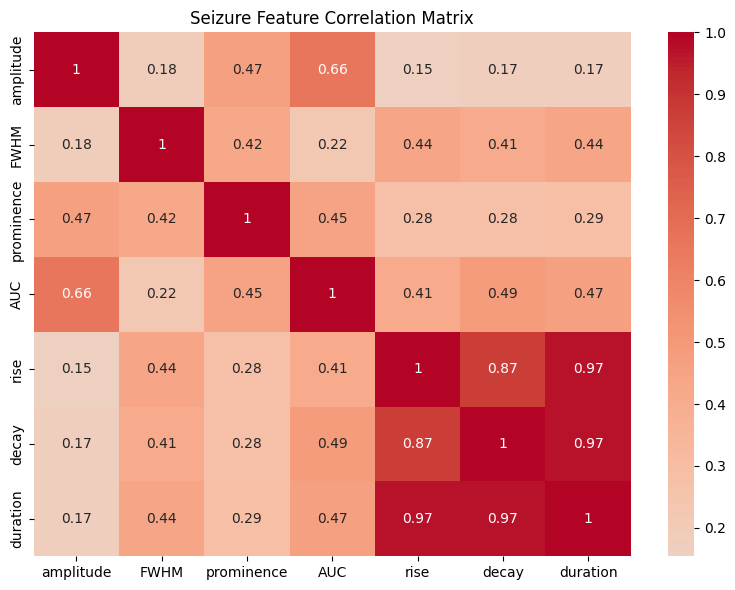

In [3]:
display(analysis_df[feature_cols].describe().round(4))

corr = analysis_df[feature_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Seizure Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(fig_dir / "feature_correlation_heatmap.tiff", dpi=300, format="tiff")
plt.show()

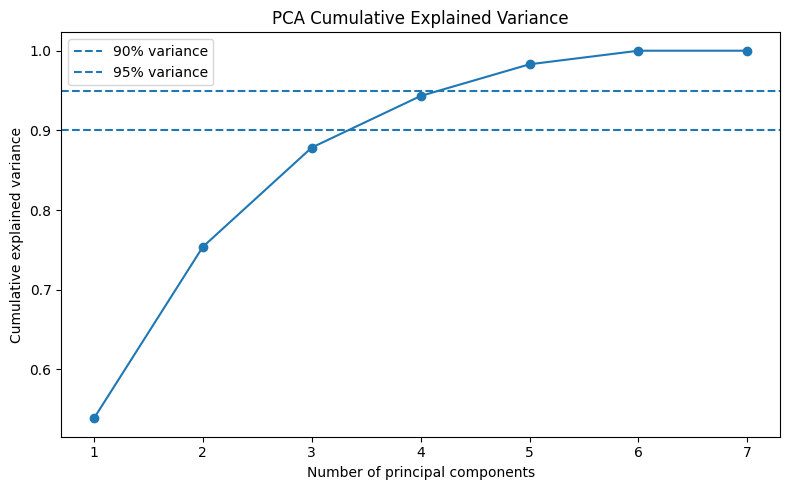

PCA shape: (527, 5)
Explained variance by retained PCs:
[0.53850926 0.21528127 0.12463172 0.06474316 0.03979959]


In [4]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.90, linestyle="--", label="90% variance")
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "pca_cumulative_variance.tiff", dpi=300, format="tiff")
plt.show()

n_pcs = min(5, X_scaled.shape[1])
pca = PCA(n_components=n_pcs)
X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)
print("Explained variance by retained PCs:")
print(pca.explained_variance_ratio_)

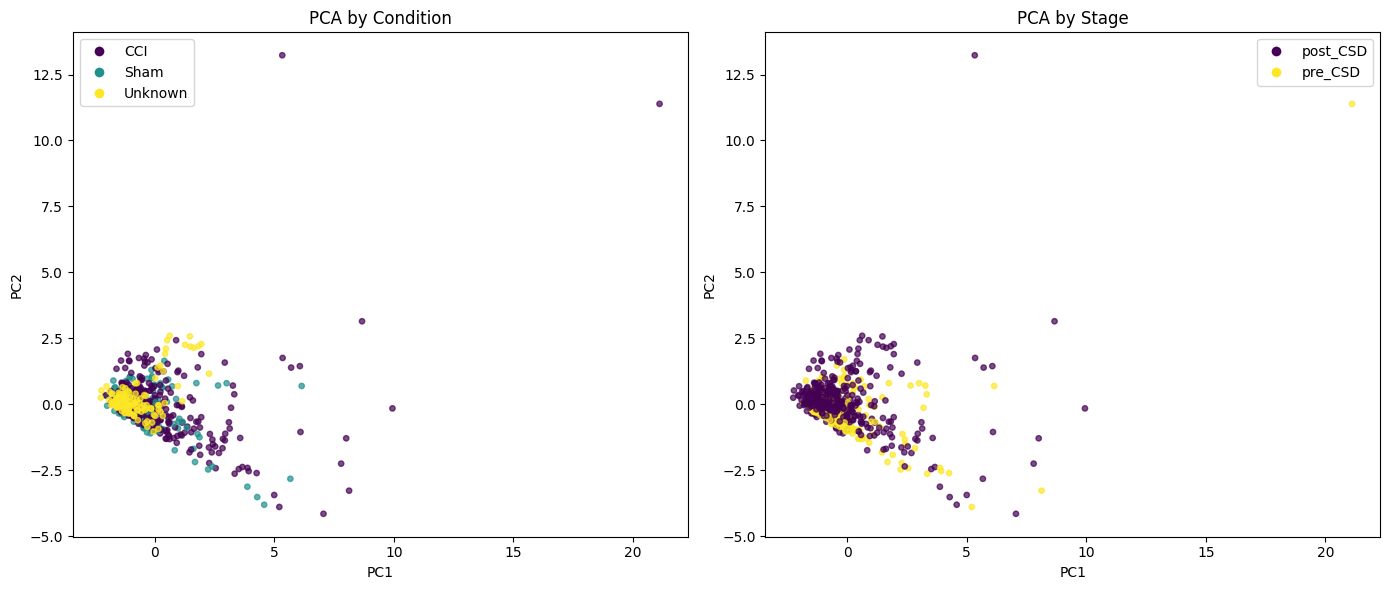

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, color_col, title in zip(
    axes,
    ["condition", "stage"],
    ["PCA by Condition", "PCA by Stage"]
):
    labels = analysis_df[color_col].astype("category")
    codes = labels.cat.codes

    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=codes,
        s=15,
        alpha=0.7
    )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)

    handles = [
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            label=cat,
            markerfacecolor=scatter.cmap(scatter.norm(code)),
            markersize=8
        )
        for code, cat in enumerate(labels.cat.categories)
    ]
    ax.legend(handles=handles)

plt.tight_layout()
plt.savefig(fig_dir / "pca_metadata_scatter.tiff", dpi=300, format="tiff")
plt.show()

In [6]:
cluster_range = range(2, 11)

rows = []

for k in cluster_range:

    labels_km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    ).fit_predict(X_pca)

    rows.append({
        "method": "kmeans",
        "k": k,
        "silhouette": silhouette_score(X_pca, labels_km),
        "davies_bouldin": davies_bouldin_score(X_pca, labels_km),
        "calinski_harabasz": calinski_harabasz_score(X_pca, labels_km)
    })

    labels_h = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    ).fit_predict(X_pca)

    rows.append({
        "method": "hierarchical",
        "k": k,
        "silhouette": silhouette_score(X_pca, labels_h),
        "davies_bouldin": davies_bouldin_score(X_pca, labels_h),
        "calinski_harabasz": calinski_harabasz_score(X_pca, labels_h)
    })

    labels_gmm = GaussianMixture(
        n_components=k,
        random_state=42,
        covariance_type="full"
    ).fit_predict(X_pca)

    rows.append({
        "method": "gmm",
        "k": k,
        "silhouette": silhouette_score(X_pca, labels_gmm),
        "davies_bouldin": davies_bouldin_score(X_pca, labels_gmm),
        "calinski_harabasz": calinski_harabasz_score(X_pca, labels_gmm)
    })

metrics_df = pd.DataFrame(rows)

display(metrics_df)

metrics_path = output_dir / "seizure_clustering_k_comparison_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print("Saved:", metrics_path)

,method,k,silhouette,davies_bouldin,calinski_harabasz
0,kmeans,2,0.611629,0.991569,250.547000
1,hierarchical,2,0.510287,1.238941,206.839825
2,gmm,2,0.470101,1.704458,117.751798
3,kmeans,3,0.588096,0.850482,268.575272
4,hierarchical,3,0.506088,1.028694,237.182040
5,gmm,3,0.401074,1.333794,161.259035
6,kmeans,4,0.426219,1.098125,253.216538
7,hierarchical,4,0.504288,1.134911,230.167425
8,gmm,4,0.224468,1.498786,77.171564
9,kmeans,5,0.467533,0.743008,255.317380


Saved: ../outputs/seizure_analysis/seizure_clustering_k_comparison_metrics.csv


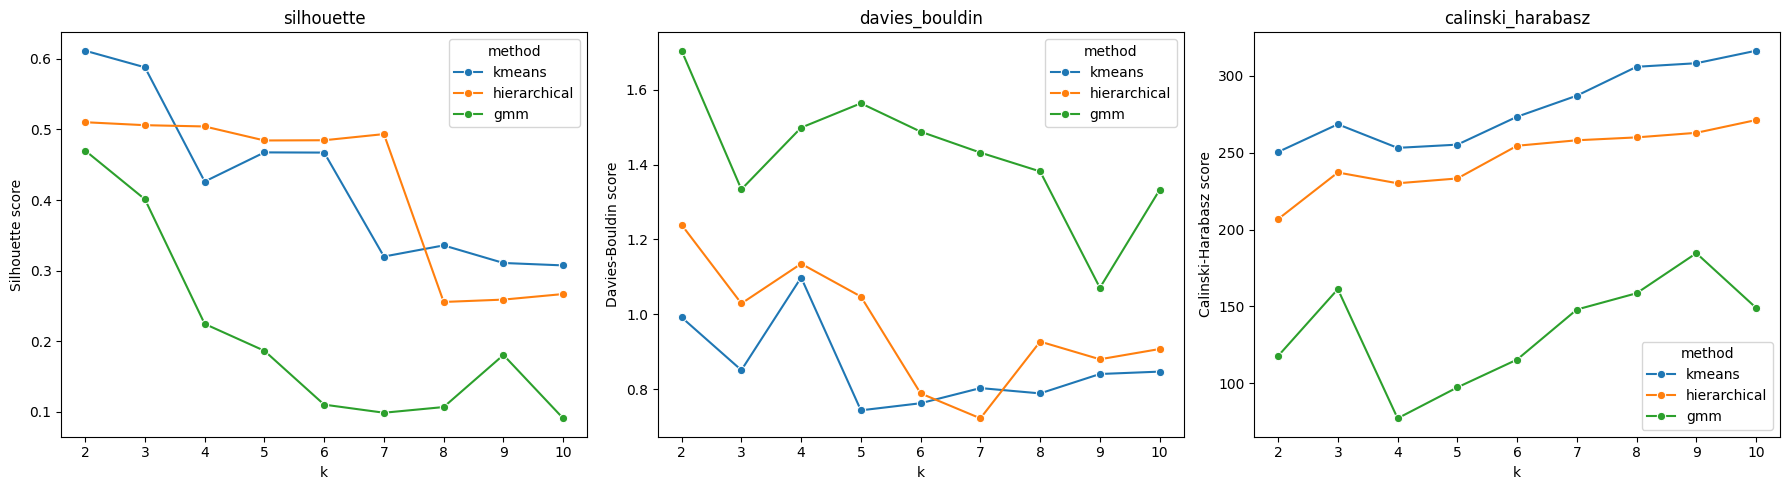

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, ylabel in zip(
    axes,
    ["silhouette", "davies_bouldin", "calinski_harabasz"],
    ["Silhouette score", "Davies-Bouldin score", "Calinski-Harabasz score"]
):
    sns.lineplot(
        data=metrics_df,
        x="k",
        y=metric,
        hue="method",
        marker="o",
        ax=ax
    )
    ax.set_title(metric)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.savefig(fig_dir / "clustering_metric_comparison.tiff", dpi=300, format="tiff")
plt.show()

In [8]:
# Adjust based on metrics and interpretability.

selected_k = 4

print("Selected k:", selected_k)

Selected k: 4


In [9]:
labels_kmeans = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=20
).fit_predict(X_pca) + 1

labels_hierarchical = AgglomerativeClustering(
    n_clusters=selected_k,
    linkage="ward"
).fit_predict(X_pca) + 1

labels_gmm = GaussianMixture(
    n_components=selected_k,
    random_state=42,
    covariance_type="full"
).fit_predict(X_pca) + 1

print("Adjusted Rand Index:")
print("KMeans vs Hierarchical:", adjusted_rand_score(labels_kmeans, labels_hierarchical))
print("KMeans vs GMM:", adjusted_rand_score(labels_kmeans, labels_gmm))
print("Hierarchical vs GMM:", adjusted_rand_score(labels_hierarchical, labels_gmm))

Adjusted Rand Index:
KMeans vs Hierarchical: 0.6503100157144063
KMeans vs GMM: 0.3835589346479143
Hierarchical vs GMM: 0.27946092175556164


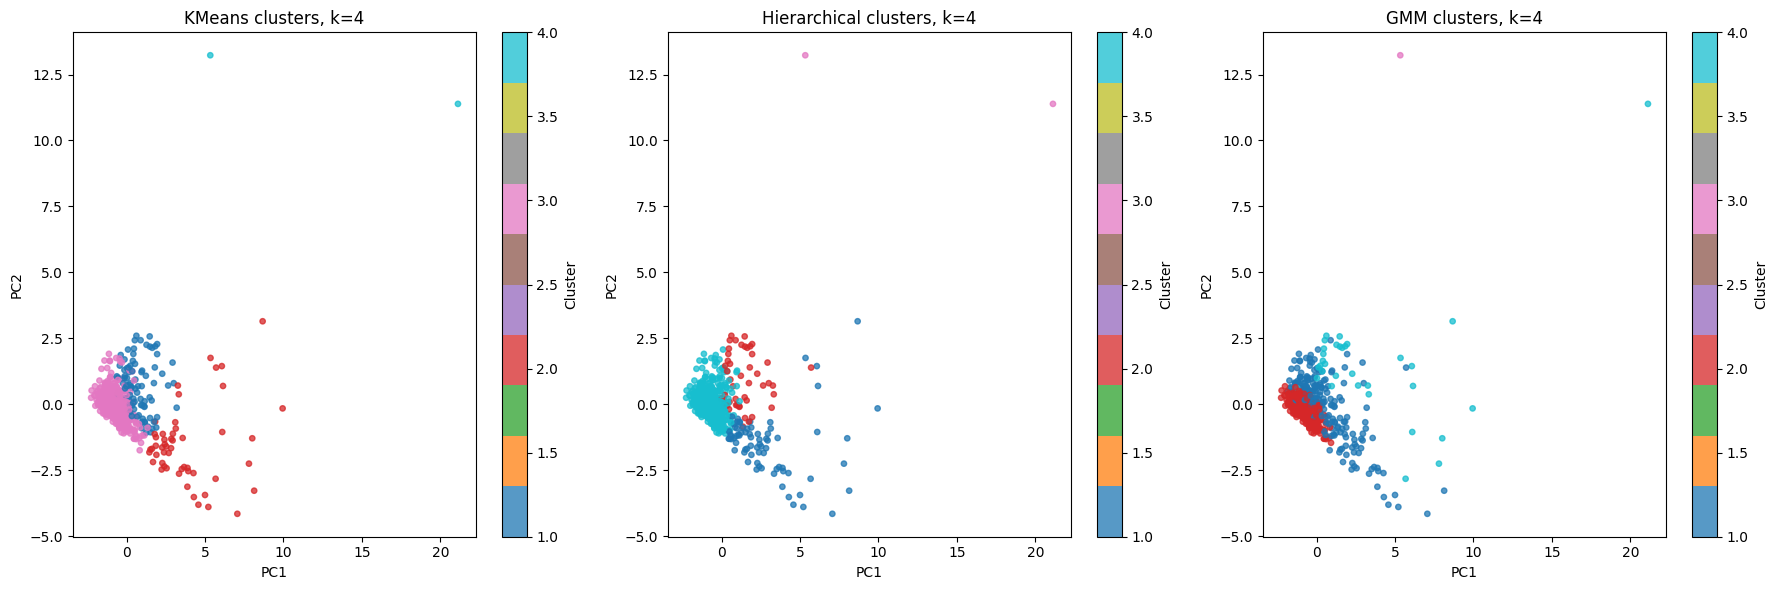

In [10]:
cluster_plot_df = analysis_df[["source_row", "event_id", "animal", "condition", "stage"]].copy()
cluster_plot_df["PC1"] = X_pca[:, 0]
cluster_plot_df["PC2"] = X_pca[:, 1]
cluster_plot_df["kmeans_cluster"] = labels_kmeans
cluster_plot_df["hierarchical_cluster"] = labels_hierarchical
cluster_plot_df["gmm_cluster"] = labels_gmm

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, title in zip(
    axes,
    ["kmeans_cluster", "hierarchical_cluster", "gmm_cluster"],
    ["KMeans", "Hierarchical", "GMM"]
):
    sc = ax.scatter(
        cluster_plot_df["PC1"],
        cluster_plot_df["PC2"],
        c=cluster_plot_df[col],
        s=15,
        alpha=0.75,
        cmap="tab10"
    )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"{title} clusters, k={selected_k}")
    fig.colorbar(sc, ax=ax, label="Cluster")

plt.tight_layout()
plt.savefig(fig_dir / "final_clusters_pca_space.tiff", dpi=300, format="tiff")
plt.show()

/home/jg/miniconda3/envs/neuropixels/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


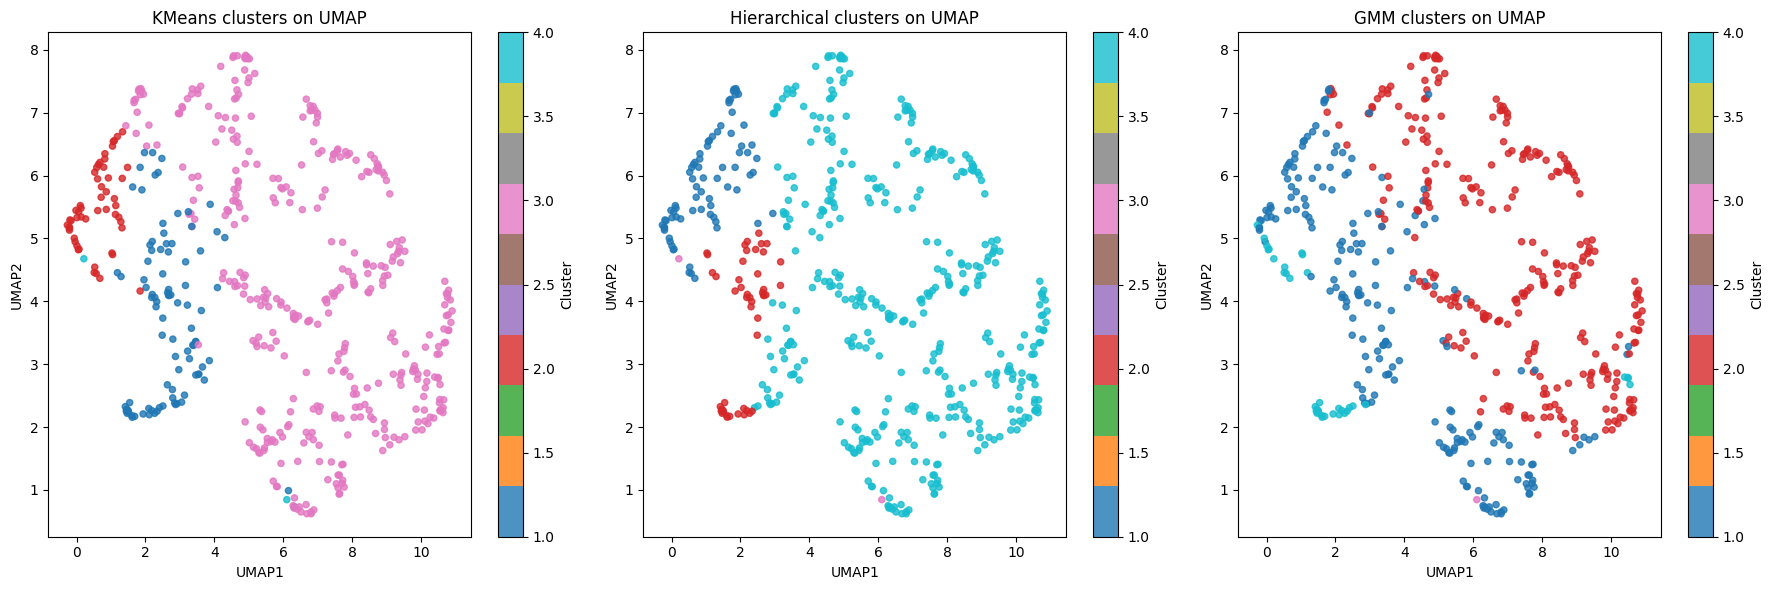

In [11]:
if UMAP_AVAILABLE:

    reducer = umap.UMAP(
        n_neighbors=min(15, len(X_pca) - 1),
        min_dist=0.1,
        random_state=42
    )

    X_umap = reducer.fit_transform(X_pca)

    cluster_plot_df["UMAP1"] = X_umap[:, 0]
    cluster_plot_df["UMAP2"] = X_umap[:, 1]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, col, title in zip(
        axes,
        ["kmeans_cluster", "hierarchical_cluster", "gmm_cluster"],
        ["KMeans", "Hierarchical", "GMM"]
    ):
        sc = ax.scatter(
            cluster_plot_df["UMAP1"],
            cluster_plot_df["UMAP2"],
            c=cluster_plot_df[col],
            s=20,
            alpha=0.8,
            cmap="tab10"
        )
        ax.set_xlabel("UMAP1")
        ax.set_ylabel("UMAP2")
        ax.set_title(f"{title} clusters on UMAP")
        fig.colorbar(sc, ax=ax, label="Cluster")

    plt.tight_layout()
    plt.savefig(fig_dir / "final_clusters_umap_space.tiff", dpi=300, format="tiff")
    plt.show()

else:
    print("UMAP not installed. Skipping UMAP visualization.")

In [12]:
cluster_assignments = analysis_df[
    ["source_row", "event_id", "animal", "condition", "stage"]
].copy()

cluster_assignments["kmeans_cluster"] = labels_kmeans
cluster_assignments["hierarchical_cluster"] = labels_hierarchical
cluster_assignments["gmm_cluster"] = labels_gmm

assignments_path = output_dir / "seizure_cluster_assignments.csv"
cluster_assignments.to_csv(assignments_path, index=False)

events_clustered = analysis_df.copy()
events_clustered["kmeans_cluster"] = labels_kmeans
events_clustered["hierarchical_cluster"] = labels_hierarchical
events_clustered["gmm_cluster"] = labels_gmm

clustered_path = output_dir / "seizure_events_clustered.csv"
events_clustered.to_csv(clustered_path, index=False)

print("Saved:")
print(assignments_path)
print(clustered_path)

Saved:
../outputs/seizure_analysis/seizure_cluster_assignments.csv
../outputs/seizure_analysis/seizure_events_clustered.csv
